# Handling fusion data results

This notebook contains a demo pipeline for analyzing GUV (Giant Unilamellar Vesicle) images. It single-frame data from .tif files.
For movie-style analysis, we apply the same tools but in a more automated format, saving more intermediate material. Here, we collect a ll the basic steps.

Jacob Kers, 2025

## Imports and Setup

In [ ]:
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from openpyxl import load_workbook
from skimage import io
from skimage import measure
import sys
import os

# Get the current working directory
current_directory = os.getcwd()
# Move one or two directories up
two_levels_up = os.path.abspath(os.path.join(current_directory, "..", ".."))
one_level_up = os.path.abspath(os.path.join(current_directory, ".."))
# Insert the path to sys.path
sys.path.insert(0, two_levels_up)

#set up local and import common tools
from common_tools import guv_binary_ops
from common_tools import guv_tools

# set up autoreload on all files
%load_ext autoreload
%autoreload 2
plt.rcParams['figure.figsize'] = [7, 5]

## collect pre-analyzed data
This excel data wraps up fusion events, one per row. Python code was used to generate kymographs [B10...py]. These kymographs were used for user classification per event. For example, user counted the number of releases ('umbrellas') , whether something was left behind ('residu') and an overall label ('fullfusion'). Then, these user-features were combined with a full analysis of the kymographs to get more deatiled features, such as event peak value, but also the temporal intensity per ring around the event location. In the following of this notebook, we'll work a few of the entries

In [15]:
#details for this analysis:
label='2_TIRF_488_001_PCPG_Chol_long'
data_source_path=Path('M:/tnw/bn/cd\Shared/Jacob/TESTdata_out/2023_Rafa/2024_10_02 membrane fusion')
xls_source  = data_source_path / "kymographs_2_TIRF_488_001_PCPG_Chol_long/B20_event_times_edits.xlsx"   
pix2um=0.1254
frame_to_ms=50

# Read the existing Excel file into a DataFrame
xls_source = data_source_path / xls_source
df = pd.read_excel(xls_source)

# Display the data read from the Excel file
print("Measured properties:")
for hdr in list(df.columns.values):
    print(hdr)

Measured properties:
event
x0
y0
t0
type(user)
docking
umbrella count
undocking?
residu?
t_r0_first appearance
t_r0_rise
t_r0_mainpeak
t_r0_maindrop
t_r0_2ndpeak
t_r0_mainpeak.1
t_r1_mainpeak
t_r2_mainpeak
t_r3_mainpeak
t_r4_mainpeak
I_center_peakval
I_center_residu10frs_perc
I_center_residu20frs_perc
I_center_residu40frs_perc
fit_D_mu^2/s
fit_R2_value
fit_zero_crossing
fit_use_it_4diff


## occurence of events by user classification


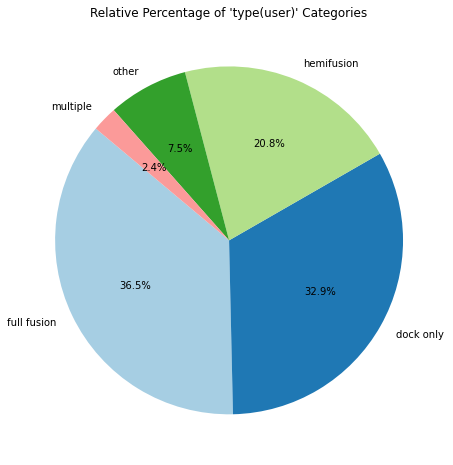

In [31]:
# Count occurrences of each category
counts = df['type(user)'].value_counts()

# Compute percentages
percentages = counts / counts.sum() * 100

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=percentages.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Relative Percentage of 'type(user)' Categories")
plt.show()  

# user class vs.residual intensity
We would expect hemifusion to exhibit a higher residual value than a full fusion event. We would expect the latter to drop all down to the original, pre-fusion intensity. However, we often observe some residual intensity, possibly due to surface-immobilized dye. By comparing residual intensities per category, we check if we can use these for an objective judgment of the type of event.



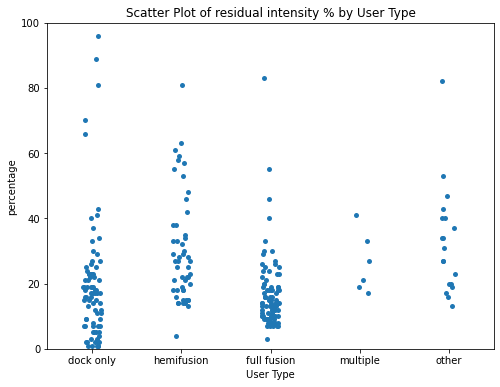

In [32]:
# Define custom category order
custom_order = ['dock only', 'hemifusion', 'full fusion',  'multiple', 'other']  # Change this to your desired order

# Convert 'type(user)' to categorical with the specified order
df['type(user)'] = pd.Categorical(df['type(user)'], categories=custom_order, ordered=True)


# Create scatter plot
plt.figure(figsize=(8, 6))
sns.stripplot(x='type(user)', y='I_center_residu20frs_perc', data=df, jitter=True, size=5)

# Labels and title
plt.xlabel("User Type")
plt.ylabel("percentage")
plt.title("Scatter Plot of residual intensity % by User Type")
plt.ylim(0,100)
plt.show()


&rarr; we do observe a difference in residual intensity. However, scatter is too large for hands-off categorization. A possible cause could be bleaching (which introduces deviations in the baseline signal). To be adressed

## Diffusion

If signal quality is high enough, we can analyze the peak intensities of rings around the fusion location. Then, we can measure passing times of the diffusion front and with that, infer a diffusion constant. We only select fits with an R2 value larger than a treshold


Text(0.5, 1.0, "Histogram of Intensity for 'full fusion' Category")

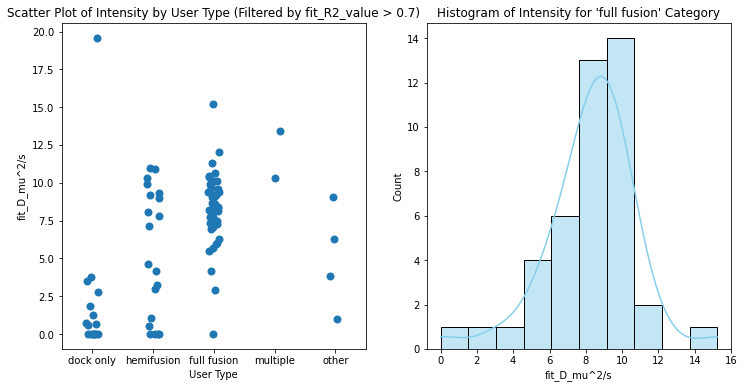

In [44]:
filtered_df = df[df['fit_R2_value'] > 0.8]
fusion_df = filtered_df[filtered_df['type(user)'] == 'full fusion']

# Create figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left Subplot: Scatter Plot
sns.stripplot(x='type(user)', y='fit_D_mu^2/s', data=filtered_df, jitter=True, size=8, order=custom_order, ax=axes[0])
axes[0].set_xlabel("User Type")
axes[0].set_ylabel("fit_D_mu^2/s")
axes[0].set_title("Scatter Plot of Intensity by User Type (Filtered by fit_R2_value > 0.7)")

# Right Subplot: Histogram for 'full fusion'
sns.histplot(fusion_df['fit_D_mu^2/s'], bins=10, kde=True, ax=axes[1], color='skyblue')
axes[1].set_xlabel("fit_D_mu^2/s")
axes[1].set_ylabel("Count")
axes[1].set_title("Histogram of Intensity for 'full fusion' Category")

&rarr; ......